# HCERL — Hybrid v2 Context-Enriched Residual Learning

Controlled ablation: V0 (96×1) through V4 (96×5).

Documentation: `docs/hybrid_v2_context/`

> Set `EXP_DIR` below to your authoritative run directory.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

REPO_ROOT = Path('..').resolve()
sys.path.insert(0, str(REPO_ROOT))

# Update to your HCERL run:
runs = sorted((REPO_ROOT / 'experiments').glob('hcerl_*'))
EXP_DIR = runs[-1] if runs else None
print('Experiment:', EXP_DIR)

if EXP_DIR is None:
    raise FileNotFoundError('No hcerl_* experiment found — run scripts/run_hcerl_experiment.py')

Experiment: /Users/lehaan/Desktop/FYP_Long_Term/experiments/hcerl_2026-07-26_180649


## 1. Experiment overview

In [2]:
with (EXP_DIR / 'config' / 'hcerl_config_frozen.json').open() as fh:
    config = json.load(fh)
print('Protocol:', config['protocol_version'])
print('Research question:', config['research_question'])
config['variant_order']

Protocol: hcerl_v1.0
Research question: Which contextual information actually improves Hybrid residual learning beyond the baseline residual-only input?


['v0_baseline', 'v1_prophet', 'v2_volatility', 'v3_cpu_std', 'v4_full']

## 2. Cohort comparison

In [3]:
cohort = pd.read_csv(EXP_DIR / 'ablation' / 'cohort_comparison.csv')
cohort

,variant_id,n,mean_day1_mae,mean_day1_rmse,mean_day1_mape,mean_peak_mae,mean_peak_rmse,mean_residual_mae_scaled,mean_residual_rmse_scaled,mean_residual_pearson_r,mean_residual_r2,mean_residual_std_ratio,mean_energy_recovery_ratio
0,v0_baseline,99,1.732136,2.372467,112.135833,3.309097,3.921800,0.094368,0.139422,0.062456,-0.341932,0.043290,0.002100
1,v1_prophet,99,1.740448,2.379958,112.009513,3.317670,3.926186,0.094517,0.139551,0.058526,-0.337480,0.066205,0.004923
2,v2_volatility,99,1.745970,2.386703,112.463413,3.324981,3.937264,0.094655,0.139771,0.045845,-0.368952,0.065377,0.004850
3,v3_cpu_std,99,1.757092,2.398176,111.869813,3.332375,3.947194,0.095023,0.140192,0.021572,-0.348996,0.077927,0.007498
4,v4_full,99,1.751930,2.387844,113.534455,3.282644,3.896924,0.094879,0.139797,0.041081,-0.352386,0.063195,0.007195


## 3. Feature contribution ranking

In [4]:
ranking = pd.read_csv(EXP_DIR / 'ablation' / 'feature_contribution_ranking.csv')
ranking

,transition,added_feature,delta_mae_mean,delta_rmse_mean,delta_pearson_r_mean,delta_std_ratio_mean,delta_r2_mean,mae_improved_fraction,pearson_improved_fraction,mae_significant,pearson_significant,rank_by_composite
0,v3_cpu_std -> v4_full,is_peak_p90,-0.005162,-0.010332,0.019508,-0.014732,-0.003389,0.444444,0.494949,False,False,1
1,v0_baseline -> v1_prophet,prophet_yhat_scaled,0.008311,0.007492,-0.003930,0.022915,0.004452,0.474747,0.515152,False,False,2
2,v1_prophet -> v2_volatility,res_roll_std_12,0.005522,0.006745,-0.012680,-0.000828,-0.031472,0.424242,0.484848,False,False,3
3,v2_volatility -> v3_cpu_std,cpu_std,0.011122,0.011472,-0.024273,0.012550,0.019956,0.363636,0.424242,False,False,4


## 4. Ablation plots

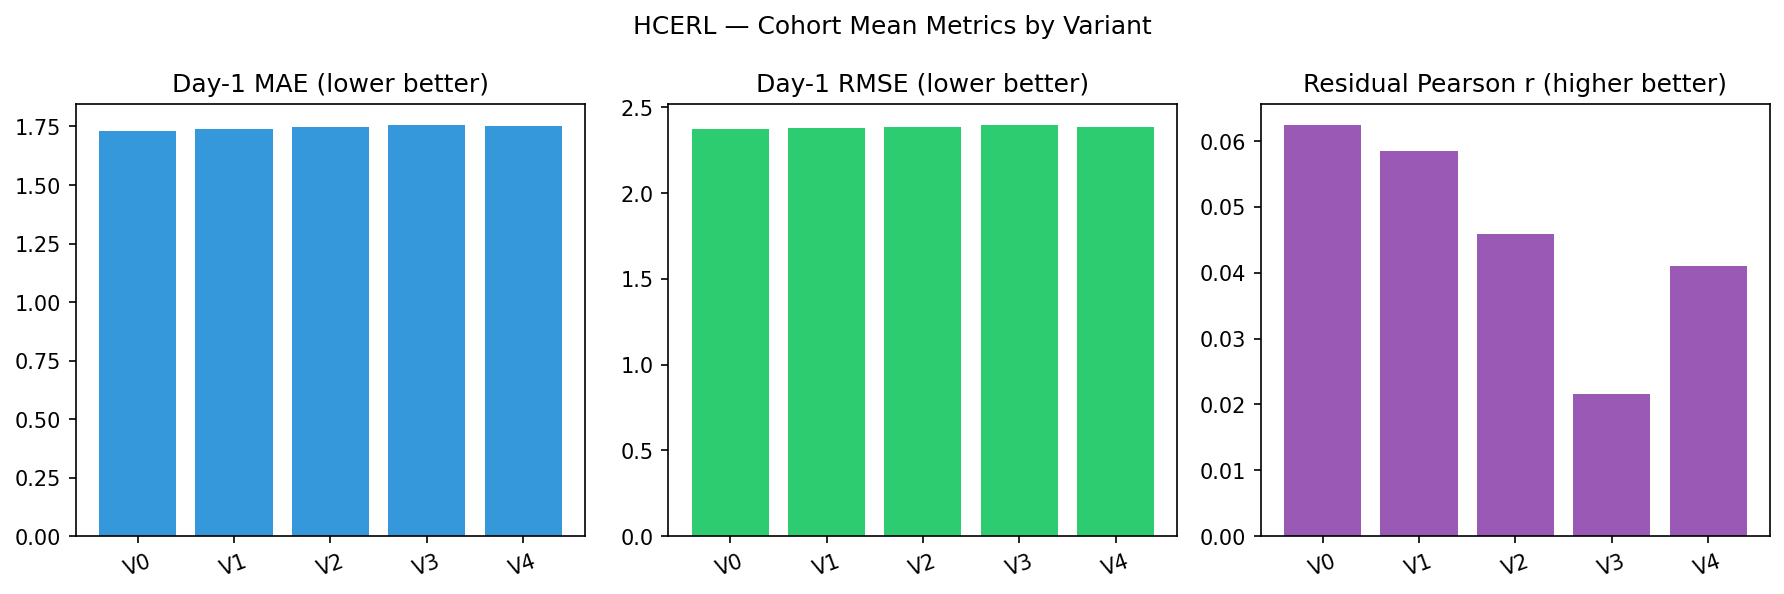

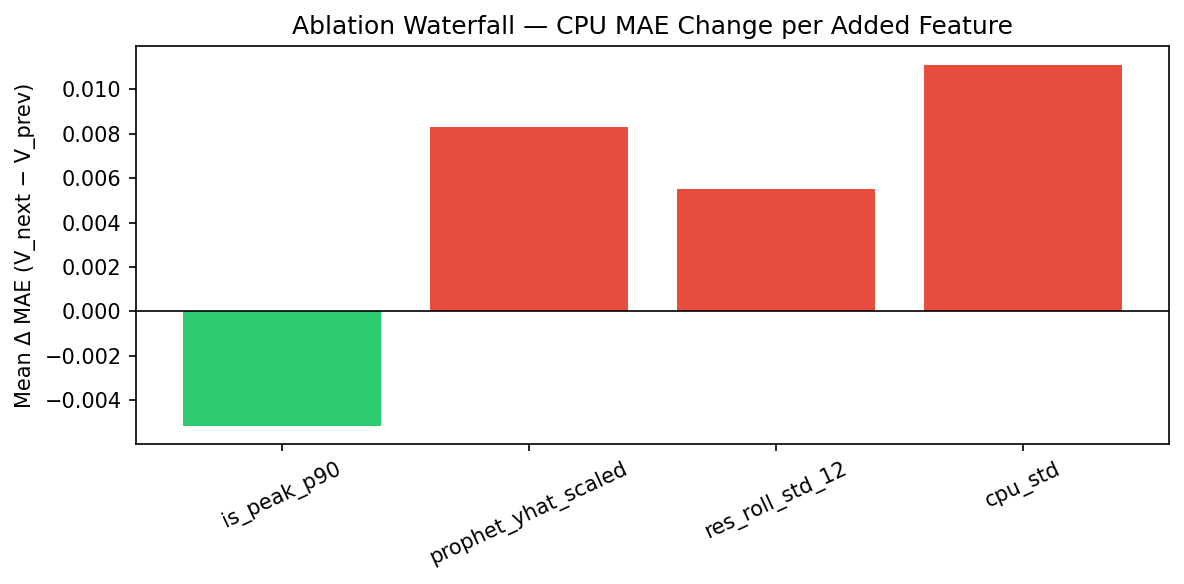

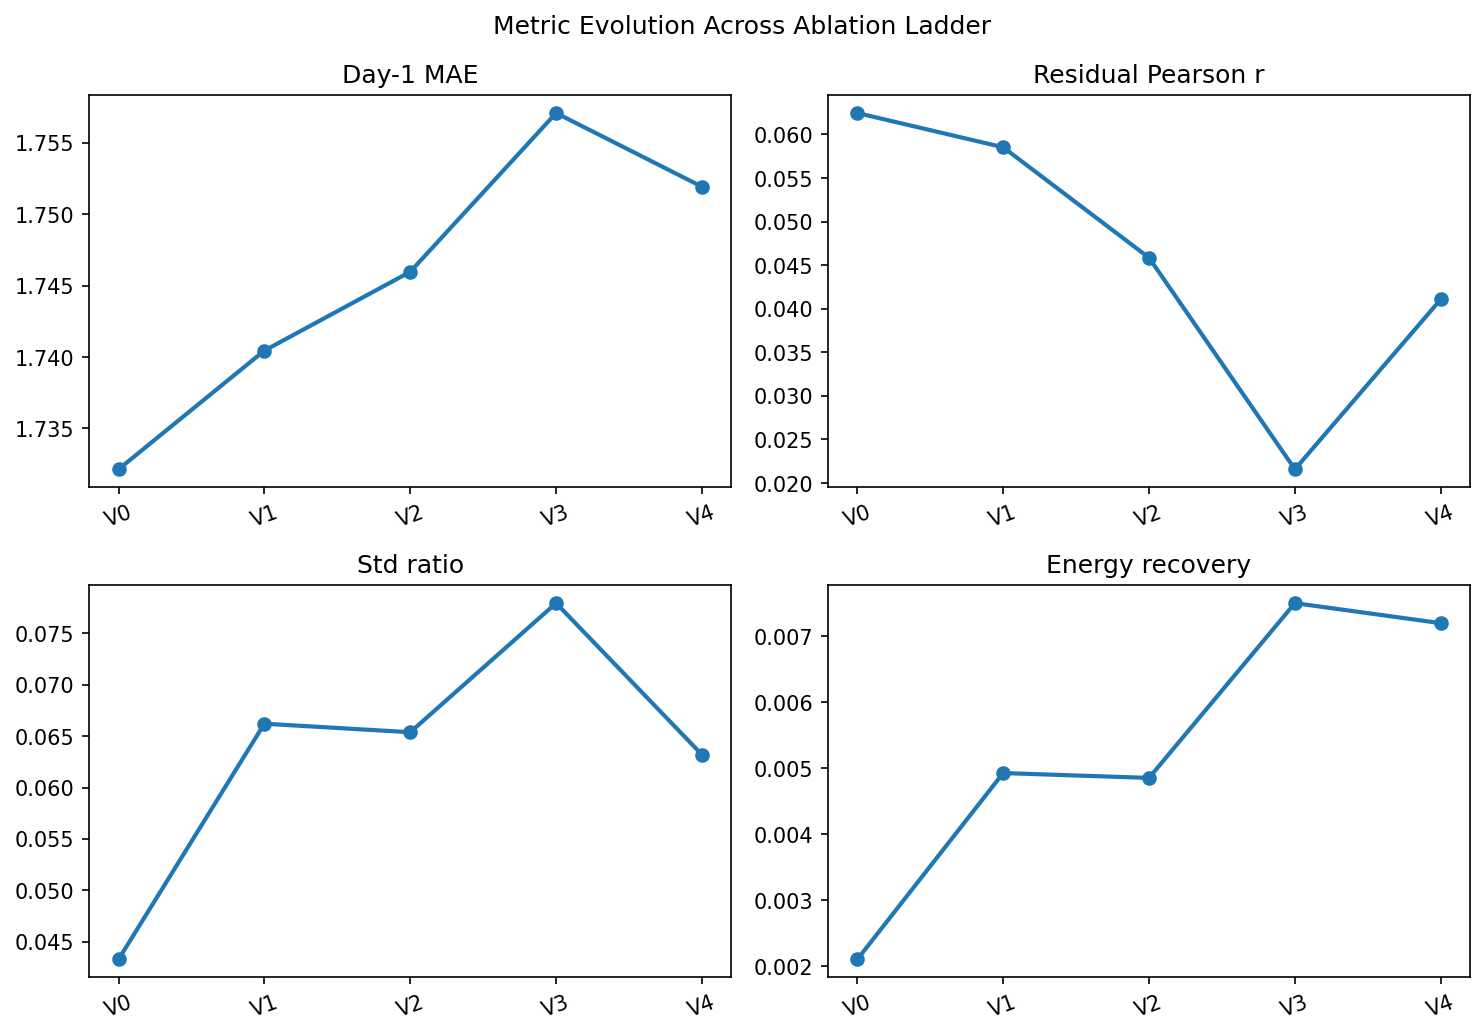

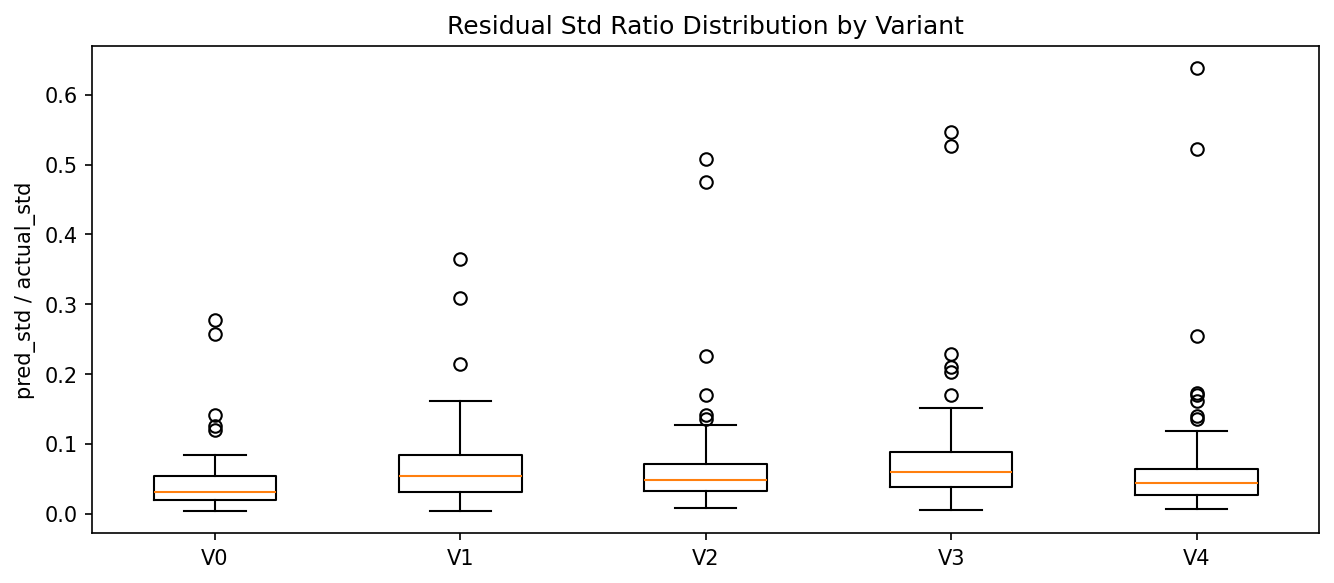

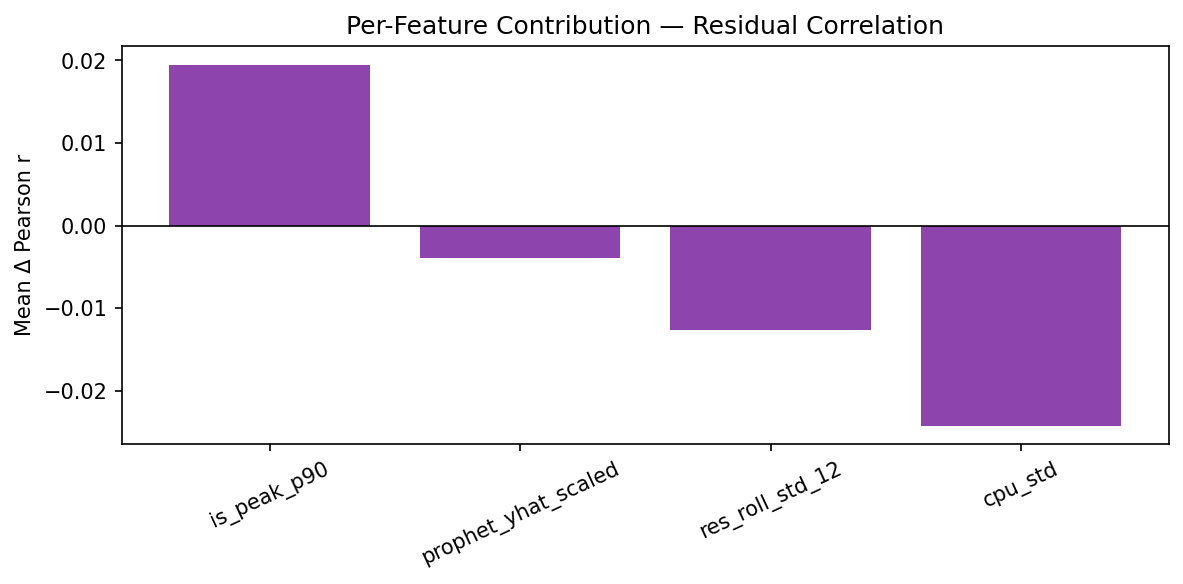

In [5]:
for name in [
    '01_overall_comparison',
    '02_ablation_waterfall_mae',
    '03_metric_evolution',
    '04_std_ratio_distribution',
    '08_feature_contribution_pearson',
]:
    p = EXP_DIR / 'plots' / f'{name}.png'
    if p.exists():
        display(Image(filename=str(p)))

## 5. Per-variant extended metrics

In [6]:
frames = []
for vid in config['variant_order']:
    df = pd.read_csv(EXP_DIR / 'variants' / vid / 'evaluation' / 'evaluation_extended.csv')
    df['variant_id'] = vid
    frames.append(df)
all_eval = pd.concat(frames, ignore_index=True)
all_eval.groupby('variant_id')[['day1_mae','day1_rmse','residual_pearson_r','residual_std_ratio']].mean()

,day1_mae,day1_rmse,residual_pearson_r,residual_std_ratio
variant_id,,,,
v0_baseline,1.732136,2.372467,0.062456,0.043290
v1_prophet,1.740448,2.379958,0.058526,0.066205
v2_volatility,1.745970,2.386703,0.045845,0.065377
v3_cpu_std,1.757092,2.398176,0.021572,0.077927
v4_full,1.751930,2.387844,0.041081,0.063195


## 6. Paired statistical tests

In [7]:
with (EXP_DIR / 'ablation' / 'paired_tests.json').open() as fh:
    paired = json.load(fh)
rows = []
for tr in paired['transitions']:
    for metric, stats in tr['metrics'].items():
        rows.append({
            'transition': tr['transition'],
            'metric': metric,
            'mean_delta': stats['mean_delta'],
            'cohens_d': stats['cohens_d'],
            'bootstrap_ci_low': stats['bootstrap']['ci_low'],
            'bootstrap_ci_high': stats['bootstrap']['ci_high'],
            'wilcoxon_p': stats['wilcoxon']['pvalue'],
        })
pd.DataFrame(rows)

,transition,metric,mean_delta,cohens_d,bootstrap_ci_low,bootstrap_ci_high,wilcoxon_p
0,v0_baseline -> v1_prophet,day1_mae,0.008311,0.195359,0.000965,0.017625,3.442156e-01
1,v0_baseline -> v1_prophet,day1_rmse,0.007492,0.156128,-0.000566,0.018201,3.232741e-01
2,v0_baseline -> v1_prophet,day1_mape,-0.126321,-0.061404,-0.583282,0.217325,7.402083e-01
3,v0_baseline -> v1_prophet,peak_mae,0.008573,0.215541,0.000875,0.016418,2.366197e-02
4,v0_baseline -> v1_prophet,peak_rmse,0.004386,0.098981,-0.004523,0.012958,3.652620e-01
5,v0_baseline -> v1_prophet,residual_mae_scaled,0.000149,0.130538,-0.000062,0.000386,6.907090e-01
6,v0_baseline -> v1_prophet,residual_rmse_scaled,0.000129,0.105089,-0.000098,0.000381,7.402083e-01
7,v0_baseline -> v1_prophet,residual_pearson_r,-0.003930,-0.034181,-0.027179,0.018894,7.640514e-01
8,v0_baseline -> v1_prophet,residual_r2,0.004452,0.066461,-0.006268,0.019672,3.828962e-01
9,v0_baseline -> v1_prophet,residual_std_ratio,0.022915,1.068283,0.018886,0.027323,7.271412e-18


## 7. Training curves

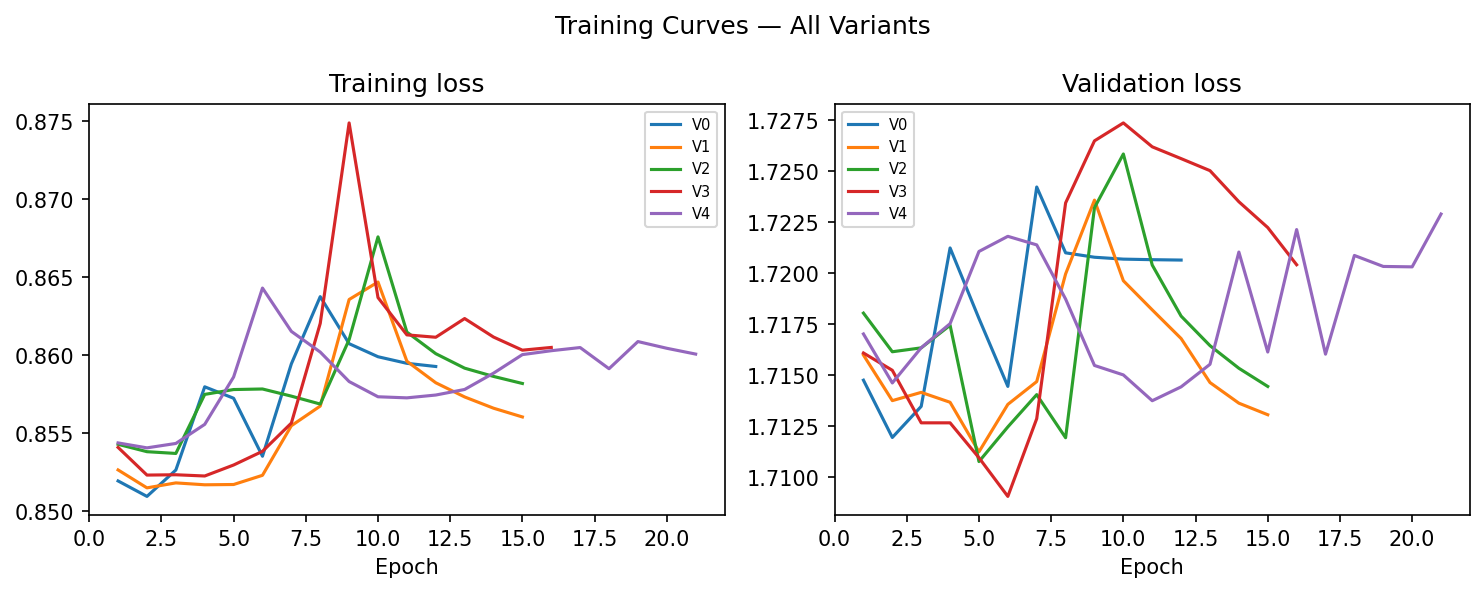

In [8]:
display(Image(filename=str(EXP_DIR / 'plots' / '07_training_curves.png')))

## 8. Case studies

In [9]:
with (EXP_DIR / 'case_studies' / 'case_studies.json').open() as fh:
    cases = json.load(fh)
pd.DataFrame(cases['cases']).T

,container_id,v0_mae,best_mae,delta_mae,v0_pearson_r,best_pearson_r,explanation
largest_improvement,c_12441,1.818224,1.634537,-0.183687,-0.219892,0.089007,Largest MAE gain (Δ=-0.184 pp): context featur...
median_improvement,c_12164,0.75542,0.757279,0.001859,0.002585,-0.07722,Typical cohort response (Δ MAE=0.002): moderat...
no_improvement,c_12193,0.319901,0.319943,0.000042,-0.076214,0.075988,Near-zero MAE change (Δ=0.000): context channe...
performance_degradation,c_12237,17.395699,18.094562,0.698862,0.049126,0.395652,Performance degraded (Δ MAE=0.699): added comp...


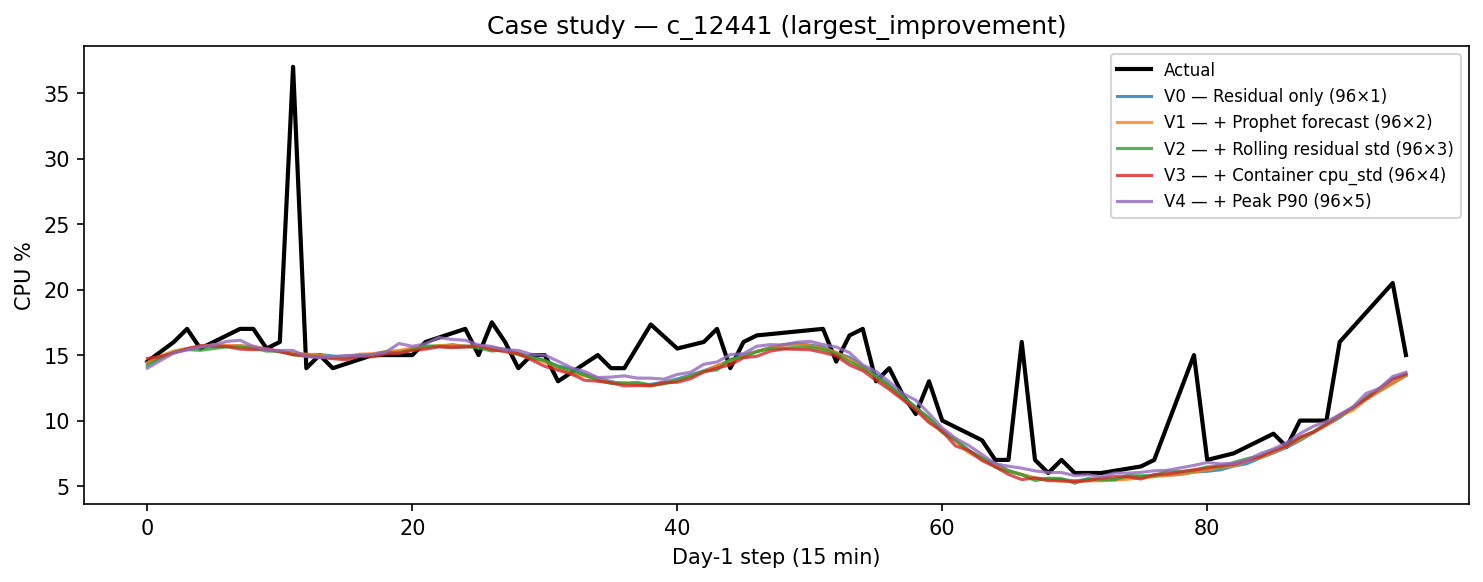

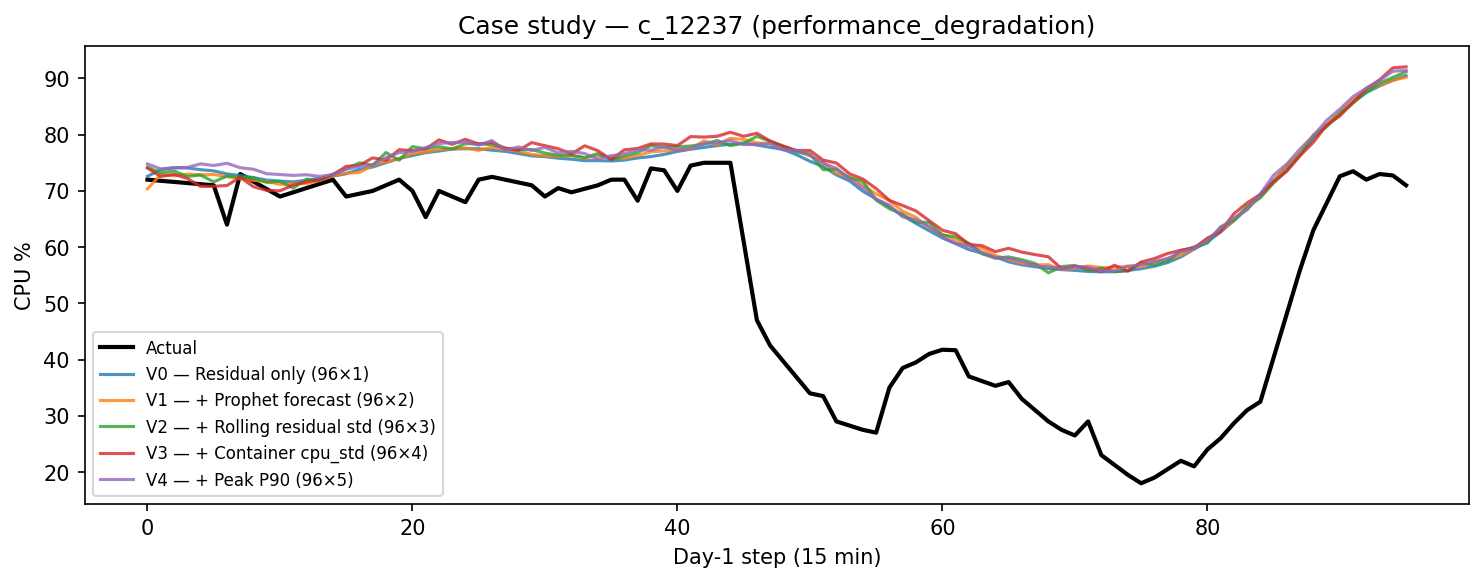

In [10]:
for name in ['largest_improvement','performance_degradation']:
    p = list((EXP_DIR / 'plots').glob(f'09_case_study_{name}_*.png'))
    if p:
        display(Image(filename=str(p[0])))

## 9. Final report

In [11]:
with (EXP_DIR / 'reports' / 'final_report.json').open() as fh:
    report = json.load(fh)
print('Recommended:', report['recommended_variant'])
print(report['recommendation_rationale'])
print()
for q, a in report['explicit_answers'].items():
    print(f'{q}: {a}')

Recommended: v0_baseline
V0 — Residual only (96×1) achieves near-best cohort MAE (1.732) with the fewest context channels among variants within 0.01 pp of the best.

1_context_improves_forecasting: No clear improvement
2_most_contributing_feature: is_peak_p90
3_least_contributing_feature: cpu_std
4_prophet_vs_statistical: Prophet level context
5_peak_features_help: Yes
6_practically_meaningful: No (MAE Δ=0.00%)
7_replace_baseline: Keep baseline — simpler model preferred


## 10. Conclusions

See `reports/final_report.md` in the experiment directory.